In [29]:
#importation des bibliothèques

import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [30]:
#importation du jeu de données

df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")



In [31]:
#analyse des données


#Dimensions
print("Dimensions:",df.shape)

#Types de chaque colonne
#print("Type colonnes:",df.types)

#valeurs manquantes par colonnes
print("Valeurs manquantes:",df.isnull().sum())

#statistiques de base
print("statistiques de base:",df.describe)



Dimensions: (2240, 29)
Valeurs manquantes: ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
statistiques de base: <bound method NDFrame.describe of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0   

<Axes: xlabel='Income', ylabel='Count'>

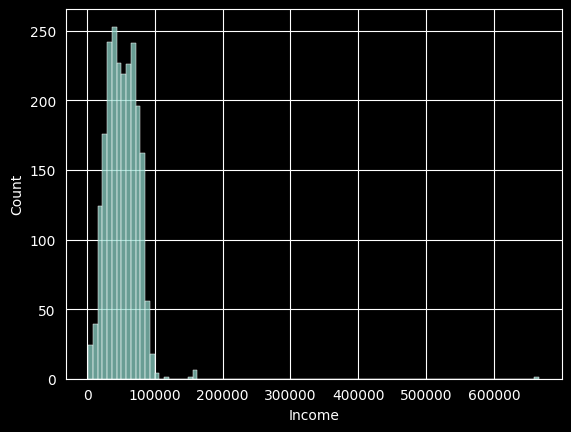

In [32]:
sns.histplot(df['Income']) #distribution d'une variable
#sns.boxplot(df['Total_spent']) #répérer les autliers

In [33]:
#encodage des variables catégorielles

le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

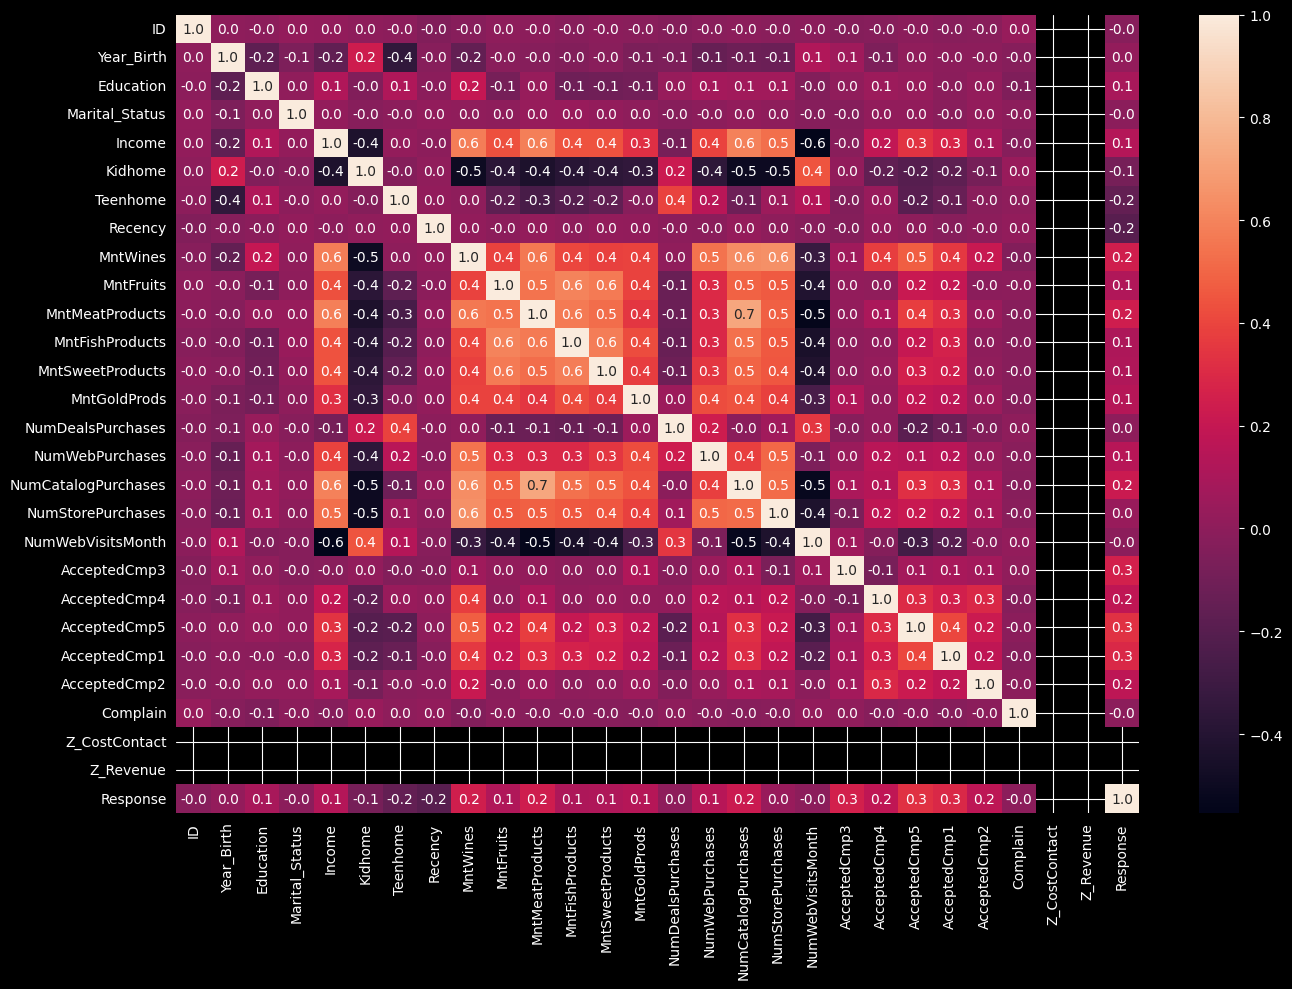

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".1f")
plt.tight_layout()
plt.show()

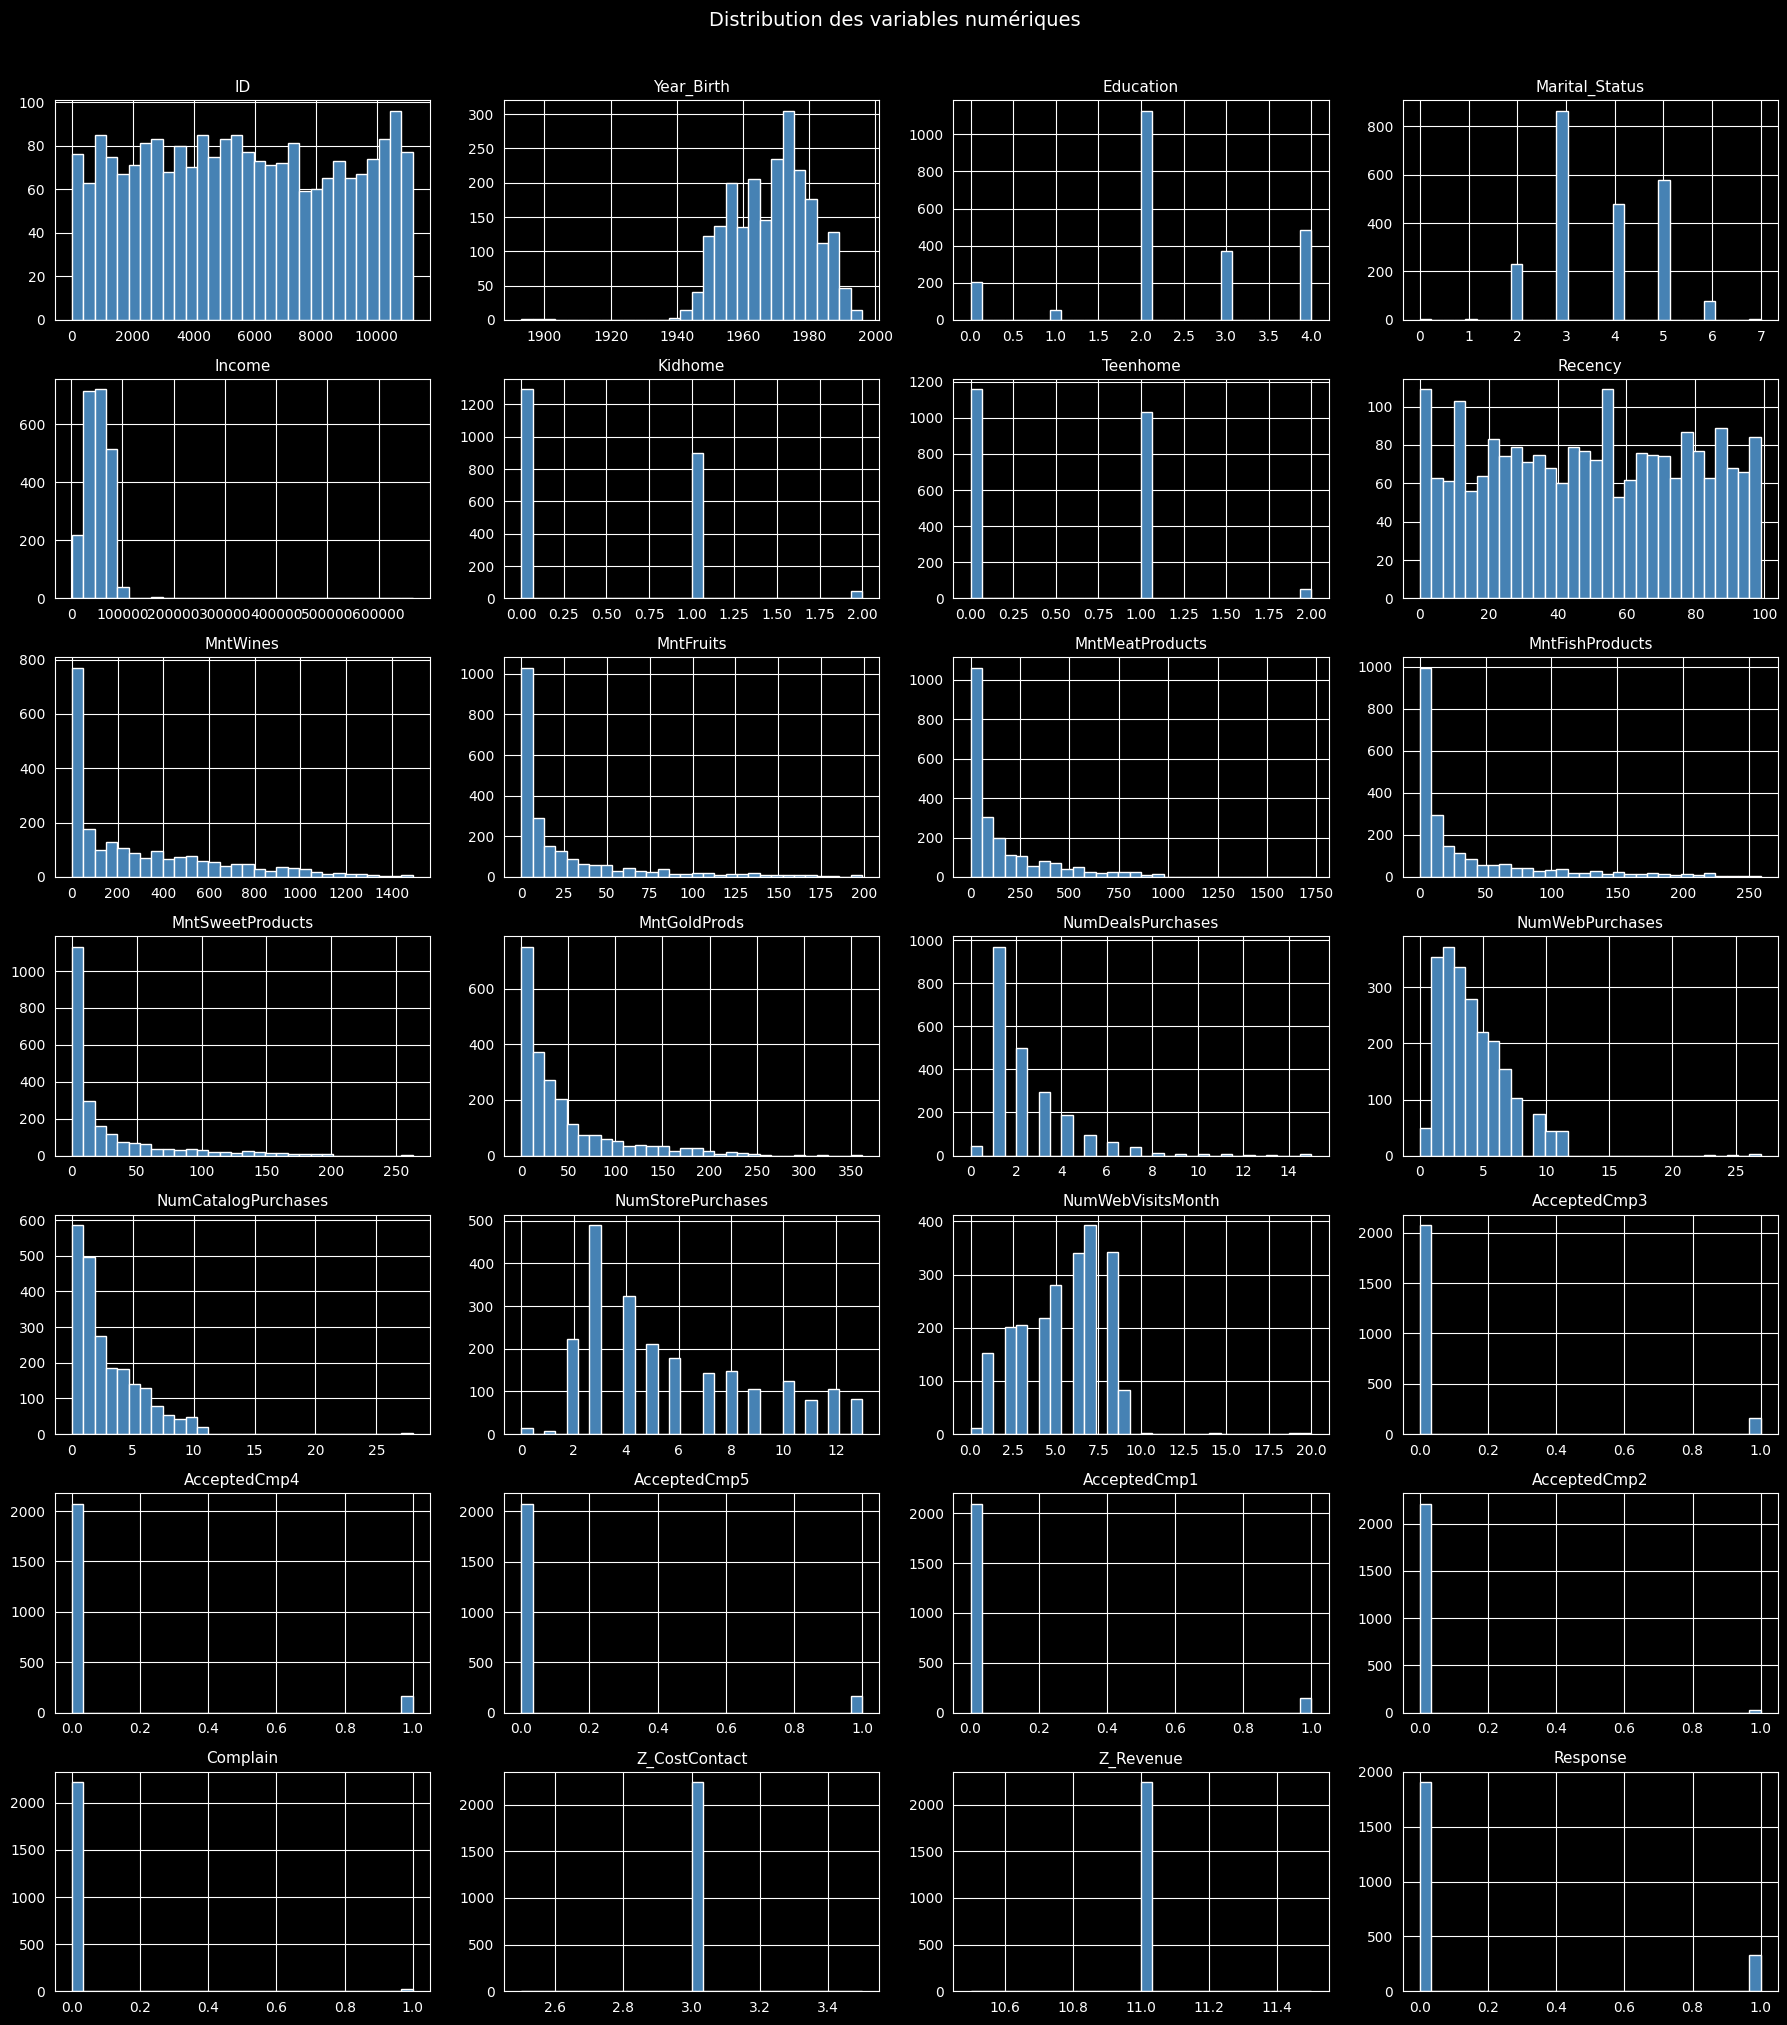

In [35]:
# Scatter plots croisés sur les variables clés (corrélation directe)
key_vars = ['Income', 'Total_spent', 'MntWines', 'MntMeatProducts',
            'NumCatalogPurchases', 'Kidhome', 'Age']

sns.pairplot(df[key_vars], plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
plt.suptitle("Corrélations directes entre variables clés", y=1.02, fontsize=13)
plt.show()

# Variables numériques uniquement
num_cols = df.select_dtypes(include='number').columns

# Histogrammes pour chaque variable
fig, axes = plt.subplots(nrows=(len(num_cols) + 3) // 4, ncols=4, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables numériques", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [37]:
print(df)

         ID  Year_Birth  Education  Marital_Status   Income  Kidhome  \
0      5524        1957          2               4  58138.0        0   
1      2174        1954          2               4  46344.0        1   
2      4141        1965          2               5  71613.0        0   
3      6182        1984          2               5  26646.0        1   
4      5324        1981          4               3  58293.0        1   
...     ...         ...        ...             ...      ...      ...   
2235  10870        1967          2               3  61223.0        0   
2236   4001        1946          4               5  64014.0        2   
2237   7270        1981          2               2  56981.0        0   
2238   8235        1956          3               5  69245.0        0   
2239   9405        1954          4               3  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012       58       635  ...            